# Detecting Methane Plumes: Machine Learning for Rare Events

Methane is responsible for roughly a third of the warming we have experienced since
pre-industrial times. It is far more potent than CO2 over short timescales and it is short-lived
in the atmosphere — which together mean that stopping a methane leak produces climate benefit
quickly. That makes leak detection one of the highest-leverage mitigation activities available,
and a large fraction of leaks come from a small number of point sources: oil and gas
infrastructure, landfills, and coal mines.

Satellite instruments — TROPOMI, EMIT, GHGSat, Carbon Mapper — can now see individual plumes.
The problem is that finding them means searching enormous volumes of imagery for something that
occupies a tiny fraction of pixels.

That rarity changes the machine learning problem fundamentally, and it is the real subject of
this notebook. **Rare event detection breaks the standard evaluation habits**, and doing it
badly produces either a useless flood of false alarms or a detector that quietly misses
everything.

## The scene

We simulate a methane column enhancement retrieval: a 2D field where each pixel is an excess
concentration above background. Two things make this hard, and both are present in real
retrievals:

- **Correlated background noise.** Retrieval noise is not white. It has spatial structure from
  surface albedo variation, aerosols, and instrument artifacts.
- **Surface artifacts.** Bright or spectrally unusual surfaces produce features that can look
  like plumes. These are the dominant source of false positives in real methane retrievals.

plume pixels: 323 of 25600  (1.26%)


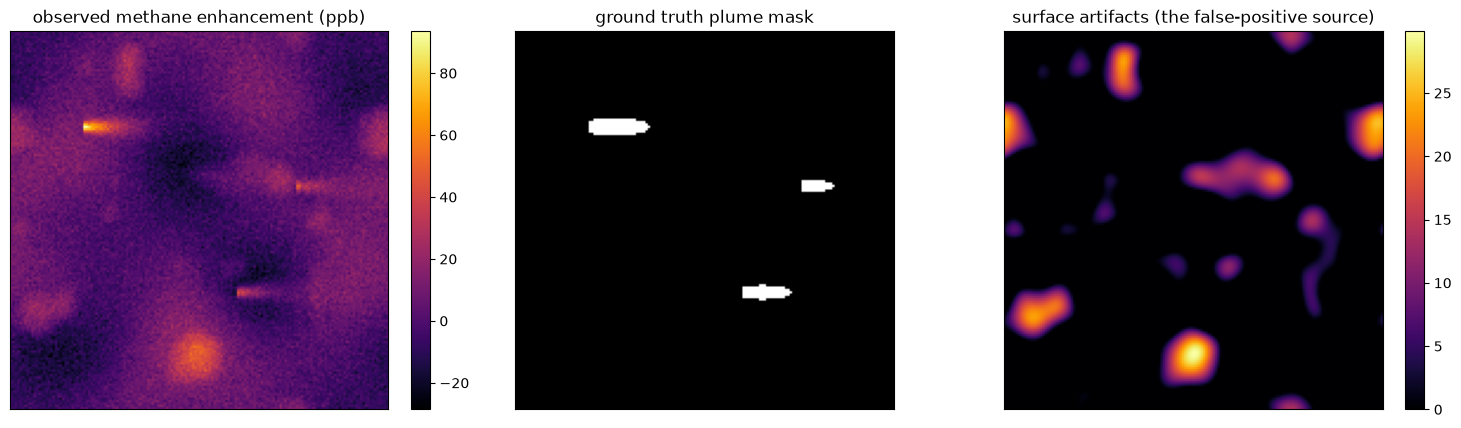

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def smooth_field(rng, shape, k=4):
    # A random field varying smoothly in space (sum of low-frequency modes).
    ny, nx = shape
    yy, xx = np.meshgrid(np.linspace(0, 1, ny), np.linspace(0, 1, nx), indexing="ij")
    f = np.zeros(shape)
    for i in range(1, k + 1):
        for j in range(1, k + 1):
            amp = rng.normal() / (i * j)
            p1, p2 = rng.uniform(0, 2 * np.pi, 2)
            f += amp * np.sin(2 * np.pi * i * xx + p1) * np.sin(2 * np.pi * j * yy + p2)
    return (f - f.mean()) / f.std()


rng = np.random.default_rng(3)
shape = (160, 160)
ny, nx = shape

# Background: correlated retrieval noise + surface artifacts + white noise.
background = 8.0 * smooth_field(rng, shape, k=3)
artifacts = 14.0 * np.clip(smooth_field(rng, shape, k=9), 0.9, None) - 12.6
scene = background + artifacts + rng.normal(0, 4.0, shape)

# Plumes: emitted from point sources, advected downwind and dispersing.
yy, xx = np.mgrid[0:ny, 0:nx]
truth = np.zeros(shape, dtype=int)
sources = [(40, 30, 1.0), (110, 95, 0.7), (65, 120, 0.45)]

for (sy, sx, strength) in sources:
    # Downwind distance along +x, with cross-wind Gaussian spread that widens with distance.
    d = xx - sx
    downwind = d > 0
    sigma = 1.4 + 0.10 * np.clip(d, 0, None)
    amp = strength * 90.0 * np.exp(-np.clip(d, 0, None) / 14.0)
    plume = np.where(downwind, amp * np.exp(-((yy - sy) ** 2) / (2 * sigma ** 2)), 0.0)
    scene = scene + plume
    truth |= (plume > 14.0).astype(int)

frac = truth.mean()
print(f"plume pixels: {truth.sum()} of {truth.size}  ({100*frac:.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
im = axes[0].imshow(scene, cmap="inferno")
axes[0].set_title("observed methane enhancement (ppb)")
plt.colorbar(im, ax=axes[0], fraction=0.046)
axes[1].imshow(truth, cmap="gray")
axes[1].set_title("ground truth plume mask")
im2 = axes[2].imshow(artifacts, cmap="inferno")
axes[2].set_title("surface artifacts (the false-positive source)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Look at the first two panels together. The plumes are visible once you know where to look, but
the artifact field produces bright compact features that resemble them. A detector keyed only on
"is this pixel bright?" will fire on both.

## Why accuracy is the wrong metric

Plume pixels are a small percentage of the scene. Consider the laziest possible detector: label
every pixel "no plume."

In [2]:
trivial_accuracy = 1 - truth.mean()
print(f"accuracy of a detector that always says 'no plume': {trivial_accuracy:.4f}")
print(f"...and it finds 0 of {truth.sum()} plume pixels.")

accuracy of a detector that always says 'no plume': 0.9874
...and it finds 0 of 323 plume pixels.


Around 99% accurate, and completely worthless. This is not a contrived example — it is the default
failure mode for any rare-event problem, and it is why **accuracy must not be used** to evaluate
detection. A model trained to minimize error will happily converge toward this solution.

The metrics that matter here come from the classification lecture:

$$\text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall} = \frac{TP}{TP+FN}$$

- **Precision** — of the pixels we flagged, how many were real plume? Low precision means
  analysts waste time chasing false alarms.
- **Recall** — of the real plume pixels, how many did we find? Low recall means leaks go
  unrepaired.

These trade off against each other, and the right balance is an operational decision, not a
statistical one.

## A simple threshold detector

The obvious approach: flag pixels above some concentration. This is a real method — variants of
it are used operationally — and it gives us a baseline.

In [3]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec_t, rec_t, thr_t = precision_recall_curve(truth.ravel(), scene.ravel())
ap_threshold = average_precision_score(truth.ravel(), scene.ravel())
print(f"threshold detector, average precision = {ap_threshold:.3f}")

threshold detector, average precision = 0.243


## Adding spatial context

A plume is not just a bright pixel — it is a *coherent structure*: elongated, connected to a
source, smoothly varying. An isolated bright pixel is far more likely to be noise or an artifact.

We give the model that context by computing, for each pixel, statistics of its neighborhood at
two scales, plus a background-subtracted value. This is the same idea as a convolutional
network's receptive field, done by hand.

In [4]:
def box_filter(a, k):
    # Mean over a k x k window, via an integral image (no scipy dependency).
    pad = k // 2
    ap = np.pad(a, pad, mode="edge")
    cs = np.cumsum(np.cumsum(ap, axis=0), axis=1)
    cs = np.pad(cs, ((1, 0), (1, 0)))
    H, W = a.shape
    return (cs[k:k+H, k:k+W] - cs[0:H, k:k+W] - cs[k:k+H, 0:W] + cs[0:H, 0:W]) / (k * k)


local5 = box_filter(scene, 5)
local15 = box_filter(scene, 15)
wide41 = box_filter(scene, 41)
excess = scene - wide41                      # local enhancement over regional background
sq5 = box_filter(scene ** 2, 5)
local_std = np.sqrt(np.clip(sq5 - local5 ** 2, 0, None))
gy, gx = np.gradient(local5)
grad = np.hypot(gy, gx)

FEATS = {
    "value": scene,
    "local mean 5x5": local5,
    "local mean 15x15": local15,
    "excess over 41x41": excess,
    "local std 5x5": local_std,
    "gradient": grad,
}
Xp = np.stack([v.ravel() for v in FEATS.values()], axis=1)
yp = truth.ravel()
print("feature matrix:", Xp.shape)

feature matrix: (25600, 6)


Now we train a classifier — and we validate it by holding out **spatial blocks**, for the same
reason as the land cover notebook. A plume spans many pixels; a random split would put most of
each plume into training and score the model on pixels adjacent to ones it memorized.

threshold detector   average precision = 0.243
context model (RF)   average precision = 0.444


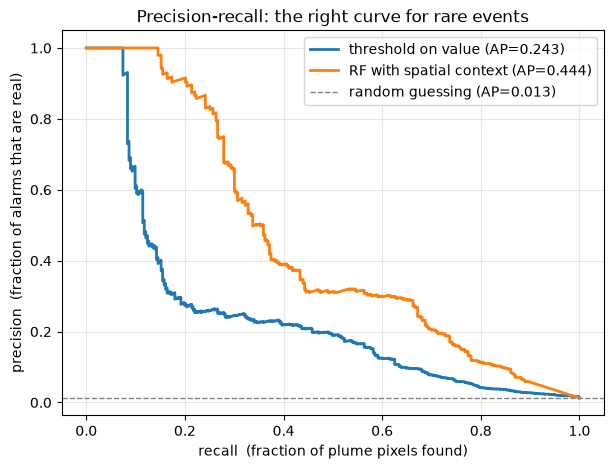

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict

by = (np.arange(ny) // (ny // 4))[:, None]
bx = (np.arange(nx) // (nx // 4))[None, :]
groups = ((by * 4 + bx) % 4).ravel()

rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                            class_weight="balanced", random_state=0, n_jobs=-1)
proba = cross_val_predict(rf, Xp, yp, cv=GroupKFold(4), groups=groups,
                          method="predict_proba")[:, 1]

ap_rf = average_precision_score(yp, proba)
prec_r, rec_r, thr_r = precision_recall_curve(yp, proba)

print(f"threshold detector   average precision = {ap_threshold:.3f}")
print(f"context model (RF)   average precision = {ap_rf:.3f}")

plt.figure(figsize=(7, 5))
plt.plot(rec_t, prec_t, lw=2, label=f"threshold on value (AP={ap_threshold:.3f})")
plt.plot(rec_r, prec_r, lw=2, label=f"RF with spatial context (AP={ap_rf:.3f})")
plt.axhline(frac, color="gray", ls="--", lw=1,
            label=f"random guessing (AP={frac:.3f})")
plt.xlabel("recall  (fraction of plume pixels found)")
plt.ylabel("precision  (fraction of alarms that are real)")
plt.title("Precision-recall: the right curve for rare events")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Note that the baseline for a precision-recall curve is not 0.5 — it is the **base rate**, the
fraction of pixels that are plume. That is what random guessing achieves. This is another reason
PR curves suit rare events better than ROC curves: an ROC curve's baseline is always 0.5
regardless of class balance, which makes rare-event detectors look far better than they are.

## Choosing an operating point

A trained model outputs a probability. Turning that into a decision requires a threshold, and
that choice is where the science meets the operational reality.

The costs are asymmetric and the asymmetry depends on the application:

- A **false positive** sends an inspection crew to a site with no leak. Cost: money and
  credibility.
- A **false negative** leaves a leak venting. Cost: continued emissions.

A screening system that flags candidates for human review can tolerate low precision. An
automated system that triggers regulatory action cannot.

best F1 at threshold 0.60:  precision=0.655  recall=0.300

 thresh  precision  recall    F1
  0.05     0.182    0.737   0.292
  0.20     0.307    0.563   0.397
  0.35     0.391    0.390   0.391
  0.50     0.507    0.337   0.405
  0.65     0.748    0.276   0.403
  0.80     0.867    0.223   0.355
  0.95     1.000    0.077   0.144


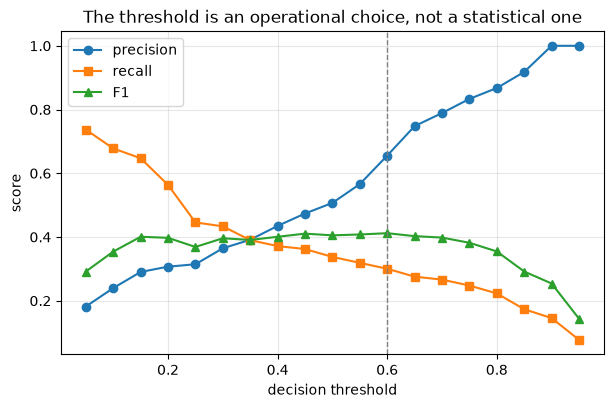

In [6]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.05, 0.95, 19)
rows = []
for t in thresholds:
    pred = (proba >= t)
    tp = np.sum(pred & (yp == 1))
    fp = np.sum(pred & (yp == 0))
    fn = np.sum(~pred & (yp == 1))
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    rows.append((t, p, r, f1_score(yp, pred, zero_division=0)))

arr = np.array(rows)
best = arr[np.argmax(arr[:, 3])]
print(f"best F1 at threshold {best[0]:.2f}:  precision={best[1]:.3f}  recall={best[2]:.3f}")
print()
print(" thresh  precision  recall    F1")
for t, p, r, f in rows[::3]:
    print(f"  {t:.2f}     {p:.3f}    {r:.3f}   {f:.3f}")

plt.figure(figsize=(7, 4.2))
plt.plot(arr[:, 0], arr[:, 1], "o-", label="precision")
plt.plot(arr[:, 0], arr[:, 2], "s-", label="recall")
plt.plot(arr[:, 0], arr[:, 3], "^-", label="F1")
plt.axvline(best[0], color="gray", ls="--", lw=1)
plt.xlabel("decision threshold")
plt.ylabel("score")
plt.title("The threshold is an operational choice, not a statistical one")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## The detection maps

Finally, the thing a practitioner actually looks at.

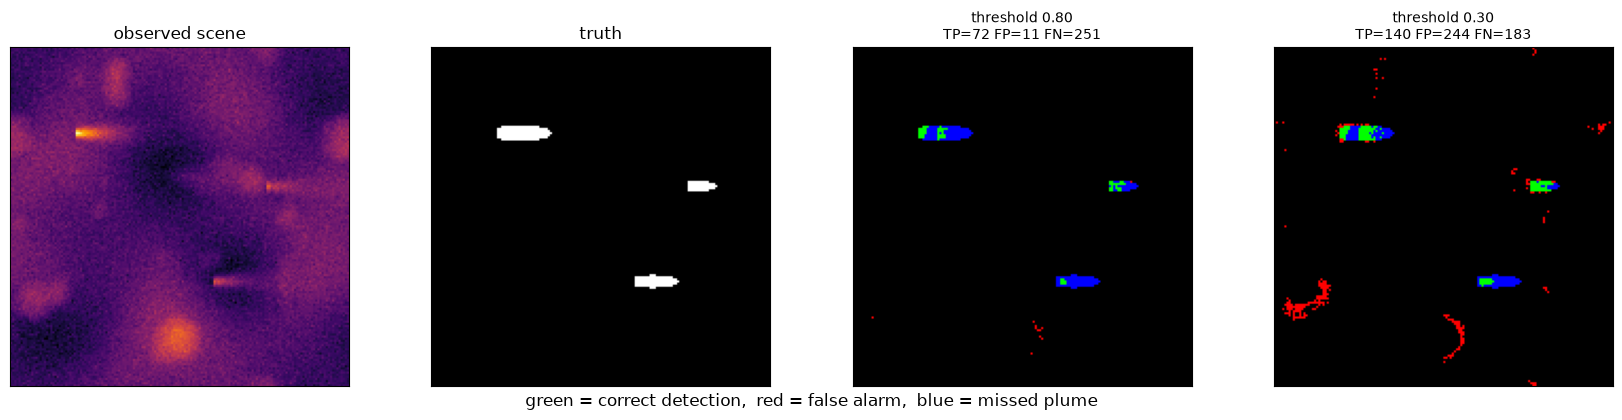

In [7]:
t_hi = 0.80   # conservative: few false alarms
t_lo = 0.30   # sensitive: catch more, tolerate false alarms

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
axes[0].imshow(scene, cmap="inferno")
axes[0].set_title("observed scene")
axes[1].imshow(truth, cmap="gray")
axes[1].set_title("truth")
for ax, t in zip(axes[2:], [t_hi, t_lo]):
    pred = (proba >= t).reshape(shape)
    disp = np.zeros(shape + (3,))
    disp[..., 0] = pred & (truth == 0)          # false positives -> red
    disp[..., 1] = pred & (truth == 1)          # true positives  -> green
    disp[..., 2] = (~pred) & (truth == 1)       # missed          -> blue
    tp = np.sum(pred & (truth == 1)); fp = np.sum(pred & (truth == 0))
    fn = np.sum((~pred) & (truth == 1))
    ax.imshow(disp)
    ax.set_title(f"threshold {t:.2f}\nTP={tp} FP={fp} FN={fn}", fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("green = correct detection,  red = false alarm,  blue = missed plume", y=0.02)
plt.tight_layout()
plt.show()

## What carries over to real data

**Plume quantification, not just detection.** Finding a plume is the first step; estimating the
emission rate matters more for policy. That requires wind speed, plume geometry, and an
inversion — and wind is usually the dominant uncertainty.

**Labels are scarce and biased.** Confirmed plume locations come from campaigns and reported
incidents, which are not a random sample of leaks. Models trained on them inherit that bias.

**Extreme imbalance.** Our scene is a few percent plume. In a real global search the rate is
orders of magnitude lower, and precision becomes correspondingly harder — at a base rate of
1 in 100,000, even a very good classifier produces mostly false alarms. This is the base rate
fallacy, and it is the central practical obstacle in operational detection.

**Physics helps.** Plumes must attach to a source, orient with the wind, and disperse in
predictable ways. Encoding those constraints — or filtering candidates by proximity to known
infrastructure — cuts false positives far more effectively than tuning the classifier.

**Deployment matters more than the model.** A detection that reaches an operator who repairs the
leak has climate value. One that sits in a results table does not. The most consequential
questions in this area are often about latency, trust, and institutional workflow rather than
about model architecture.